In [1]:
import os, sys

print("CWD:", os.getcwd())
print("Python path:")
for p in sys.path:
    print(p)

CWD: /home/student2/ofml_workspace/OpenFastML/notebooks
Python path:
/home/student2/ofml_workspace/OpenFastML/conda/envs/fastml4jets/lib/python310.zip
/home/student2/ofml_workspace/OpenFastML/conda/envs/fastml4jets/lib/python3.10
/home/student2/ofml_workspace/OpenFastML/conda/envs/fastml4jets/lib/python3.10/lib-dynload

/home/student2/ofml_workspace/OpenFastML/conda/envs/fastml4jets/lib/python3.10/site-packages
__editable__.ofml-0.0.1.finder.__path_hook__


In [2]:
from data.opendataloader import OpenDataLoader
from fastml.modules.cnn import load_qCNN
from fastml.utils.image import pad
from fastml.utils_egamma.efex import eFex_slidingwindow_mask
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc


2026-06-19 14:18:26.021089: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-19 14:18:26.021122: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-19 14:18:26.021148: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-19 14:18:26.027493: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
og_model_path = '../models/cls_qcnn/baseline_model.keras'
root_model_path = '../models/root_qcnn/baseline_model.keras'

In [5]:
signal = ak.from_parquet('../test_data/test_signal.parquet')
background = ak.from_parquet('../test_data/test_background.parquet')
signal_meta = ak.metadata_from_parquet("../test_data/test_signal.parquet")

In [6]:
print(signal_meta["columns"])

['image.list.item.list.item.list.item.list.item', 'seed_info.list.item.rho', 'seed_info.list.item.phi', 'seed_info.list.item.eta', 'seed_info.list.item.tau']


In [7]:
og_model = load_qCNN(og_model_path)
root_model = load_qCNN(root_model_path)

/home/student2/ofml_workspace/OpenFastML/conda/envs/fastml4jets/lib/python3.10/site-packages/keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


In [8]:
og_predictions = []
for dataset in [signal, background]:
    pred = og_model.predict(
        np.array(ak.flatten(dataset.image)),
        batch_size=1024,
        verbose=0
    )
    
    pred = pred[:,0,0,0]
    counts = ak.num(dataset.seed_info)
    og_predictions.append(ak.unflatten(pred, counts))
    
og_predictions = {
    "signal" : og_predictions[0],
    "background" : og_predictions[1]
}
root_predictions = []
for dataset in [signal, background]:
    pred = root_model.predict(
        np.array(ak.flatten(dataset.image)),
        batch_size=1024,
        verbose=0
    )
    
    pred = pred[:,0,0,0]
    counts = ak.num(dataset.seed_info)
    root_predictions.append(ak.unflatten(pred, counts))
    
root_predictions = {
    "signal" : root_predictions[0],
    "background" : root_predictions[1]
}

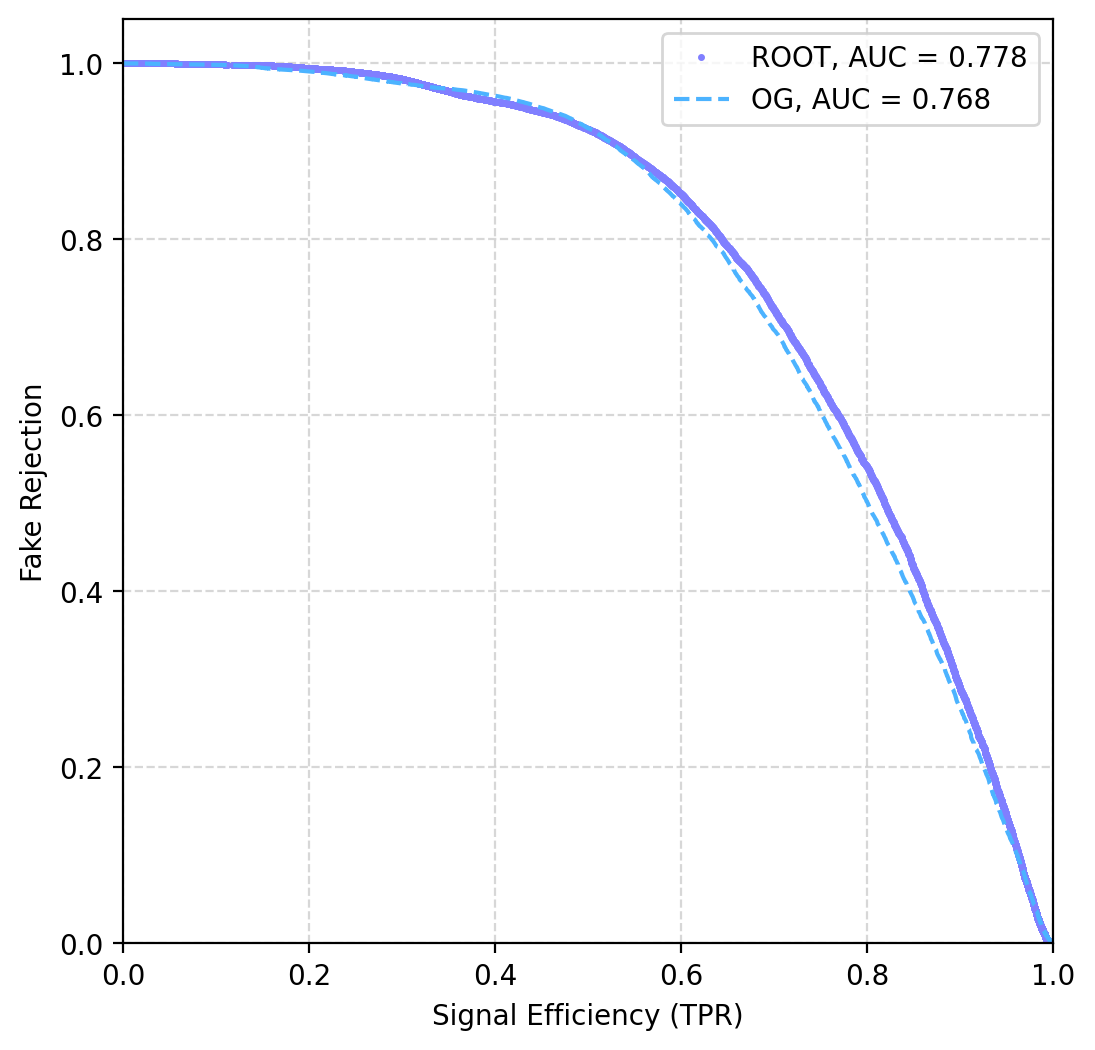

In [10]:
# ROOT predictions
y_sig_root = ak.flatten(root_predictions['signal'])
y_bkg_root = ak.flatten(root_predictions['background'][:len(y_sig_root)])

y_root = np.concatenate([np.ones_like(y_sig_root, dtype=int), np.zeros_like(y_bkg_root, dtype=int)])
s_root = np.concatenate([y_sig_root, y_bkg_root])

fpr_root, tpr_root, _ = roc_curve(y_root, s_root)
A_root = auc(fpr_root, tpr_root)

fake_rej_root = 1 - fpr_root

# OG predictions
y_sig_og = ak.flatten(og_predictions['signal'])
y_bkg_og = ak.flatten(og_predictions['background'][:len(y_sig_og)])

y_og = np.concatenate([np.ones_like(y_sig_og, dtype=int), np.zeros_like(y_bkg_og, dtype=int)])
s_og = np.concatenate([y_sig_og, y_bkg_og])

fpr_og, tpr_og, _ = roc_curve(y_og, s_og)
A_og = auc(fpr_og, tpr_og)

fake_rej_og = 1 - fpr_og

plt.figure(figsize=(6, 6), dpi=200)
plt.plot(tpr_root, fake_rej_root, ".", ms=3, color=plt.cm.cool(0.5), label=f"ROOT, AUC = {A_root:.3f}")
plt.plot(tpr_og, fake_rej_og, "--", color=plt.cm.cool(0.3), label=f"OG, AUC = {A_og:.3f}")

plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.xlabel("Signal Efficiency (TPR)")
plt.ylabel("Fake Rejection")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()

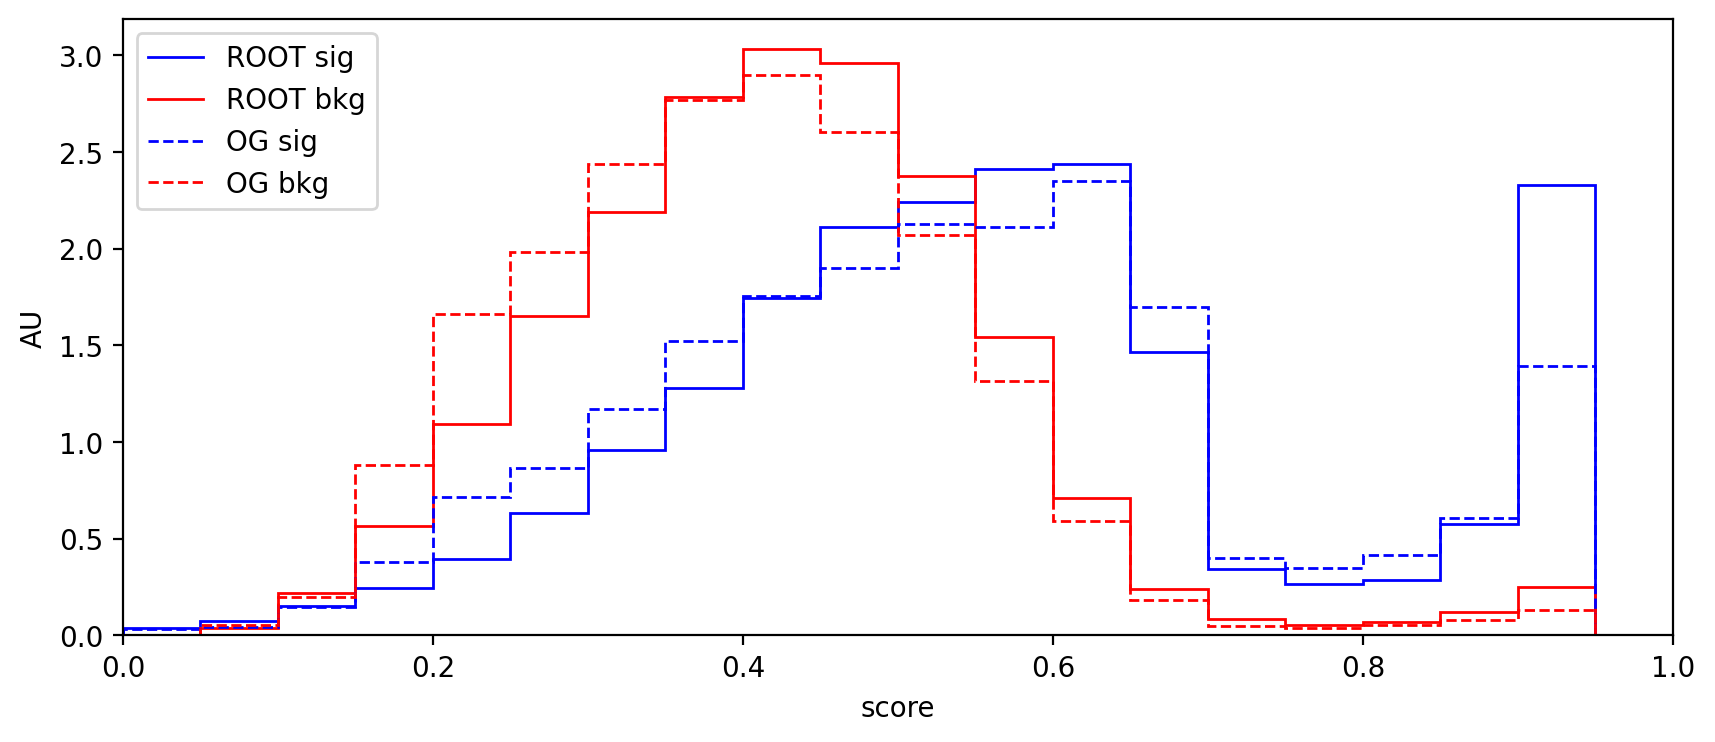

In [11]:
bin_edges = np.arange(0, 1, 0.05)

plt.figure(figsize=(10, 4), dpi=200)

# ROOT predictions
hist_root_sig, _ = np.histogram(ak.flatten(root_predictions['signal']), bins=bin_edges, density=True)
plt.stairs(hist_root_sig, bin_edges, label=f"ROOT sig", color=f"blue")

hist_root_bkg, _ = np.histogram(ak.flatten(root_predictions['background']), bins=bin_edges, density=True)
plt.stairs(hist_root_bkg, bin_edges, label=f"ROOT bkg", color=f"red")

# OG predictions
hist_og_sig, _ = np.histogram(ak.flatten(og_predictions['signal']), bins=bin_edges, density=True)
plt.stairs(hist_og_sig, bin_edges, label=f"OG sig", linestyle="--", color=f"blue")

hist_og_bkg, _ = np.histogram(ak.flatten(og_predictions['background']), bins=bin_edges, density=True)
plt.stairs(hist_og_bkg, bin_edges, label=f"OG bkg", linestyle="--", color=f"red")

plt.xlabel("score")
plt.ylabel('AU')
plt.xlim(0,1)
plt.legend()
plt.show()